# Chapter 7: Conformal Prediction — Companion Notebook

This notebook contains all the Python code from Chapter 7, with brief explanations of each step. It covers:

1. **Intuition plots** — visualising point prediction error, uncertainty types, conformity ladders
2. **Split conformal mechanics** — calibration, quartiles, and interval construction
3. **Applied: EnbPI with PyTorch + MAPIE** — conformal intervals on a feedforward forecasting model
4. **Library examples** — the same conformal prediction task using Darts and NeuralForecast

## Setup and imports

In [28]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

plt.style.use('seaborn-v0_8')

custom_palette = ["#000000", "#0072B2", "#D55E00", "#009E73", "#CC79A7", "#56B4E9", "#E69F00"]

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Source Sans Pro', 'Arial']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.titlesize'] = 18

data_folder = Path(r'C:\Users\Graeme\Documents\github\tsfwpt\das_buch\data\chapter7')

class CFG:
    data_folder = Path.cwd().parent / "data"
    img_dim1 = 12
    img_dim2 = 6
    fontsize = 18

## 1. Point prediction vs actual value

A simple linear model illustrating the distance between a predicted value and the true value. This is the fundamental problem conformal prediction addresses: quantifying how wrong our predictions might be.

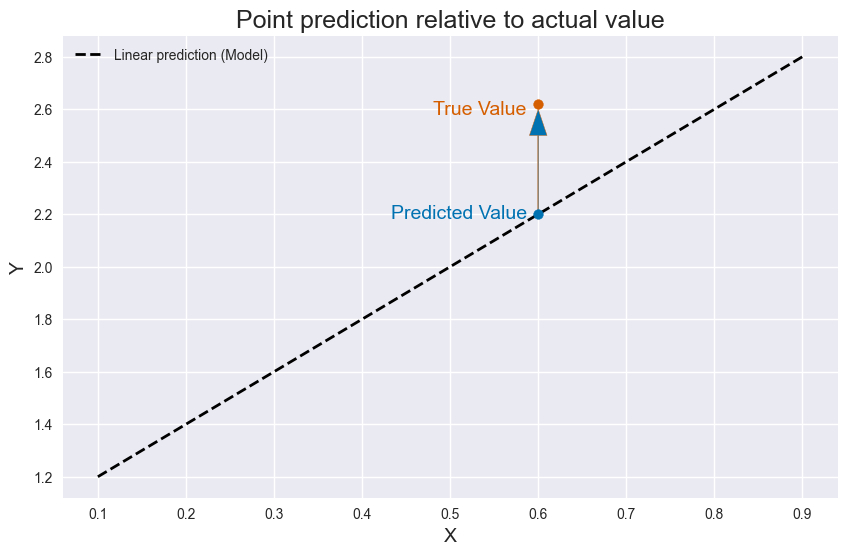

In [29]:
x = np.linspace(0.1, 0.9, 100)
y = 2 * x + 1

x_pred = 0.6
y_pred = 2 * x_pred + 1
y_true = 2.5

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, label='Linear prediction (Model)', color=custom_palette[0], linestyle='--')
ax.scatter([x_pred], [y_pred], color=custom_palette[1], zorder=5)
ax.scatter([x_pred], [y_true + 0.12], color=custom_palette[2], zorder=5)

ax.annotate('Predicted Value', (x_pred, y_pred), textcoords="offset points", 
            xytext=(-57, -3), ha='center', color=custom_palette[1])
ax.annotate('True Value', (x_pred, y_true), textcoords="offset points", 
            xytext=(-42, 15), ha='center', color=custom_palette[2])

ax.arrow(x_pred, y_pred, 0, y_true - y_pred, head_width=0.02, head_length=0.1, 
         fc=custom_palette[1], ec=custom_palette[2])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Point prediction relative to actual value')
ax.legend()
plt.grid(True)
plt.show()

## 2. Aleatoric vs epistemic uncertainty

Two clusters of data with different noise levels. High noise = high aleatoric uncertainty. Gaps with no data = high epistemic uncertainty (we don't know what happens there).

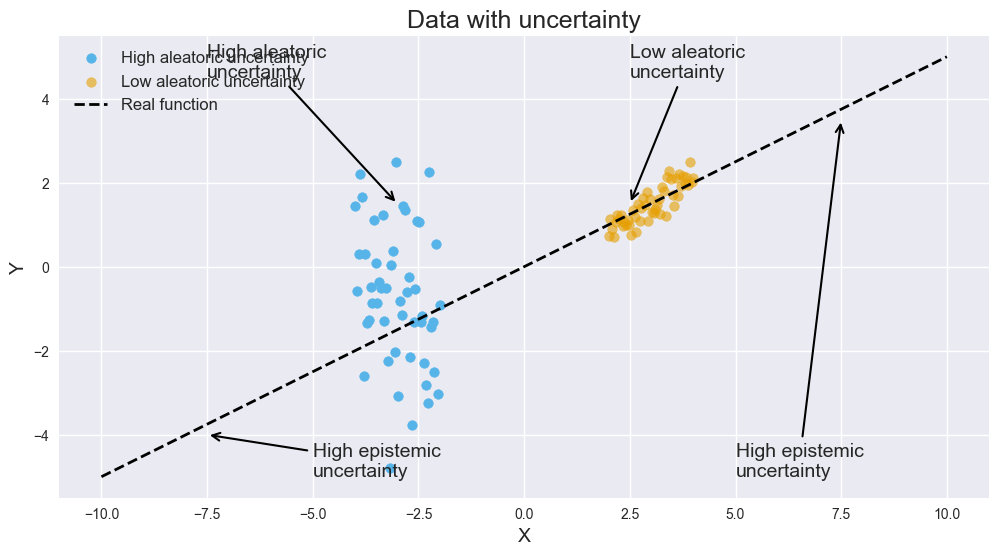

In [30]:
np.random.seed(0)
x_high = np.linspace(-4, -2, 50)
y_high = 0.3 * x_high + np.random.normal(loc=0, scale=1.5, size=50)

x_low = np.linspace(2, 4, 50)
y_low = 0.5 * x_low + np.random.normal(loc=0, scale=0.3, size=50)

x_line = np.linspace(-10, 10, 200)
y_line = 0.5 * x_line

fig, ax = plt.subplots(figsize=(CFG.img_dim1, CFG.img_dim2))
ax.scatter(x_high, y_high, color=custom_palette[5], label='High aleatoric uncertainty')
ax.scatter(x_low, y_low, color=custom_palette[6], alpha=0.6, label='Low aleatoric uncertainty')
ax.plot(x_line, y_line, 'k--', label='Real function')

ax.annotate('High aleatoric\nuncertainty', xy=(-3.0, 1.5), xytext=(-7.5, 4.5),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'), fontsize=14)
ax.annotate('Low aleatoric\nuncertainty', xy=(2.5, 1.5), xytext=(2.5, 4.5),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'), fontsize=14)
ax.annotate('High epistemic\nuncertainty', xy=(-7.5, -4), xytext=(-5, -5),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'), fontsize=14)
ax.annotate('High epistemic\nuncertainty', xy=(7.5, 3.5), xytext=(5, -5),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'), fontsize=14)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Data with uncertainty')
ax.legend(loc='upper left', fontsize=12)
plt.show()

## 3. Measuring non-conformity with absolute error

We fit a linear regression and highlight two predicted points: one close to the line (low AE, high conformity) and one far from it (high AE, low conformity). This is the intuition behind non-conformity scores.

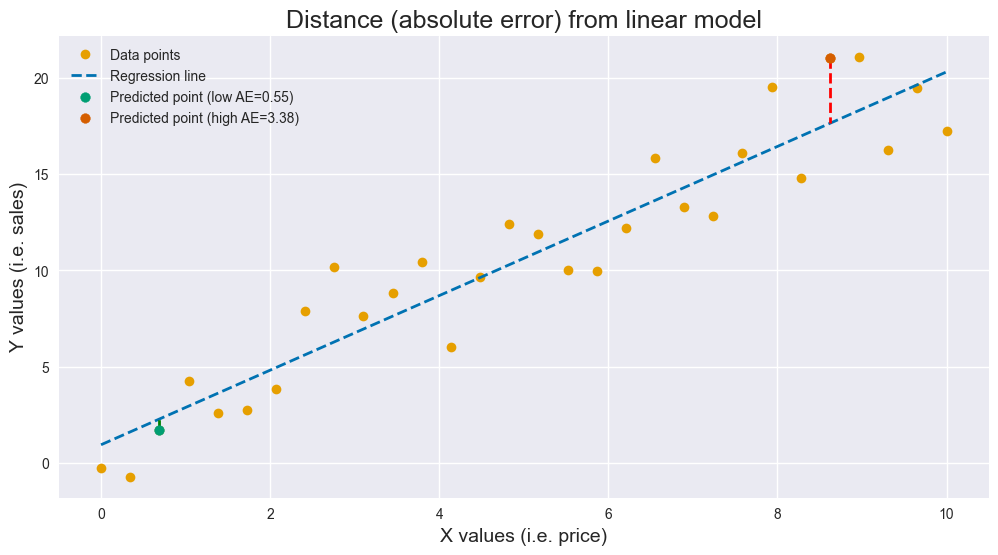

In [31]:
np.random.seed(235987)
x = np.linspace(0, 10, 30)
y = 2 * x + 1 + np.random.normal(scale=2, size=30)

p, residuals, _, _, _ = np.polyfit(x, y, 1, full=True)
fitted_y = np.poly1d(p)(x)
absolute_errors = np.abs(y - fitted_y)

sorted_indices = np.argsort(absolute_errors)
point_near_index = sorted_indices[3]
point_far_index = sorted_indices[-2]

point_near = (x[point_near_index], y[point_near_index])
point_far = (x[point_far_index], y[point_far_index])
fitted_near = fitted_y[point_near_index]
fitted_far = fitted_y[point_far_index]
ae_near = absolute_errors[point_near_index]
ae_far = absolute_errors[point_far_index]

fig, ax = plt.subplots()
ax.plot(x, y, 'o', label='Data points', color=custom_palette[6])
ax.plot(x, fitted_y, '--', label='Regression line', color=custom_palette[1])
ax.scatter(*point_near, color=custom_palette[3], label=f'Predicted point (low AE={ae_near:.2f})', zorder=5)
ax.scatter(*point_far, color=custom_palette[2], label=f'Predicted point (high AE={ae_far:.2f})', zorder=5)

ax.plot([point_near[0], point_near[0]], [point_near[1], fitted_near], 'g--')
ax.plot([point_far[0], point_far[0]], [point_far[1], fitted_far], 'r--')

ax.set_xlabel('X values (i.e. price)')
ax.set_ylabel('Y values (i.e. sales)')
ax.set_title('Distance (absolute error) from linear model')
ax.legend()
plt.grid(True)
plt.show()

## 4. Conformity ladder

We take a regression dataset, highlight one point (violet), and show its position on the conformity ladder. Then we shift it to an extreme position and see how all rankings change. This demonstrates why full conformal prediction requires refitting — moving one point changes everything.

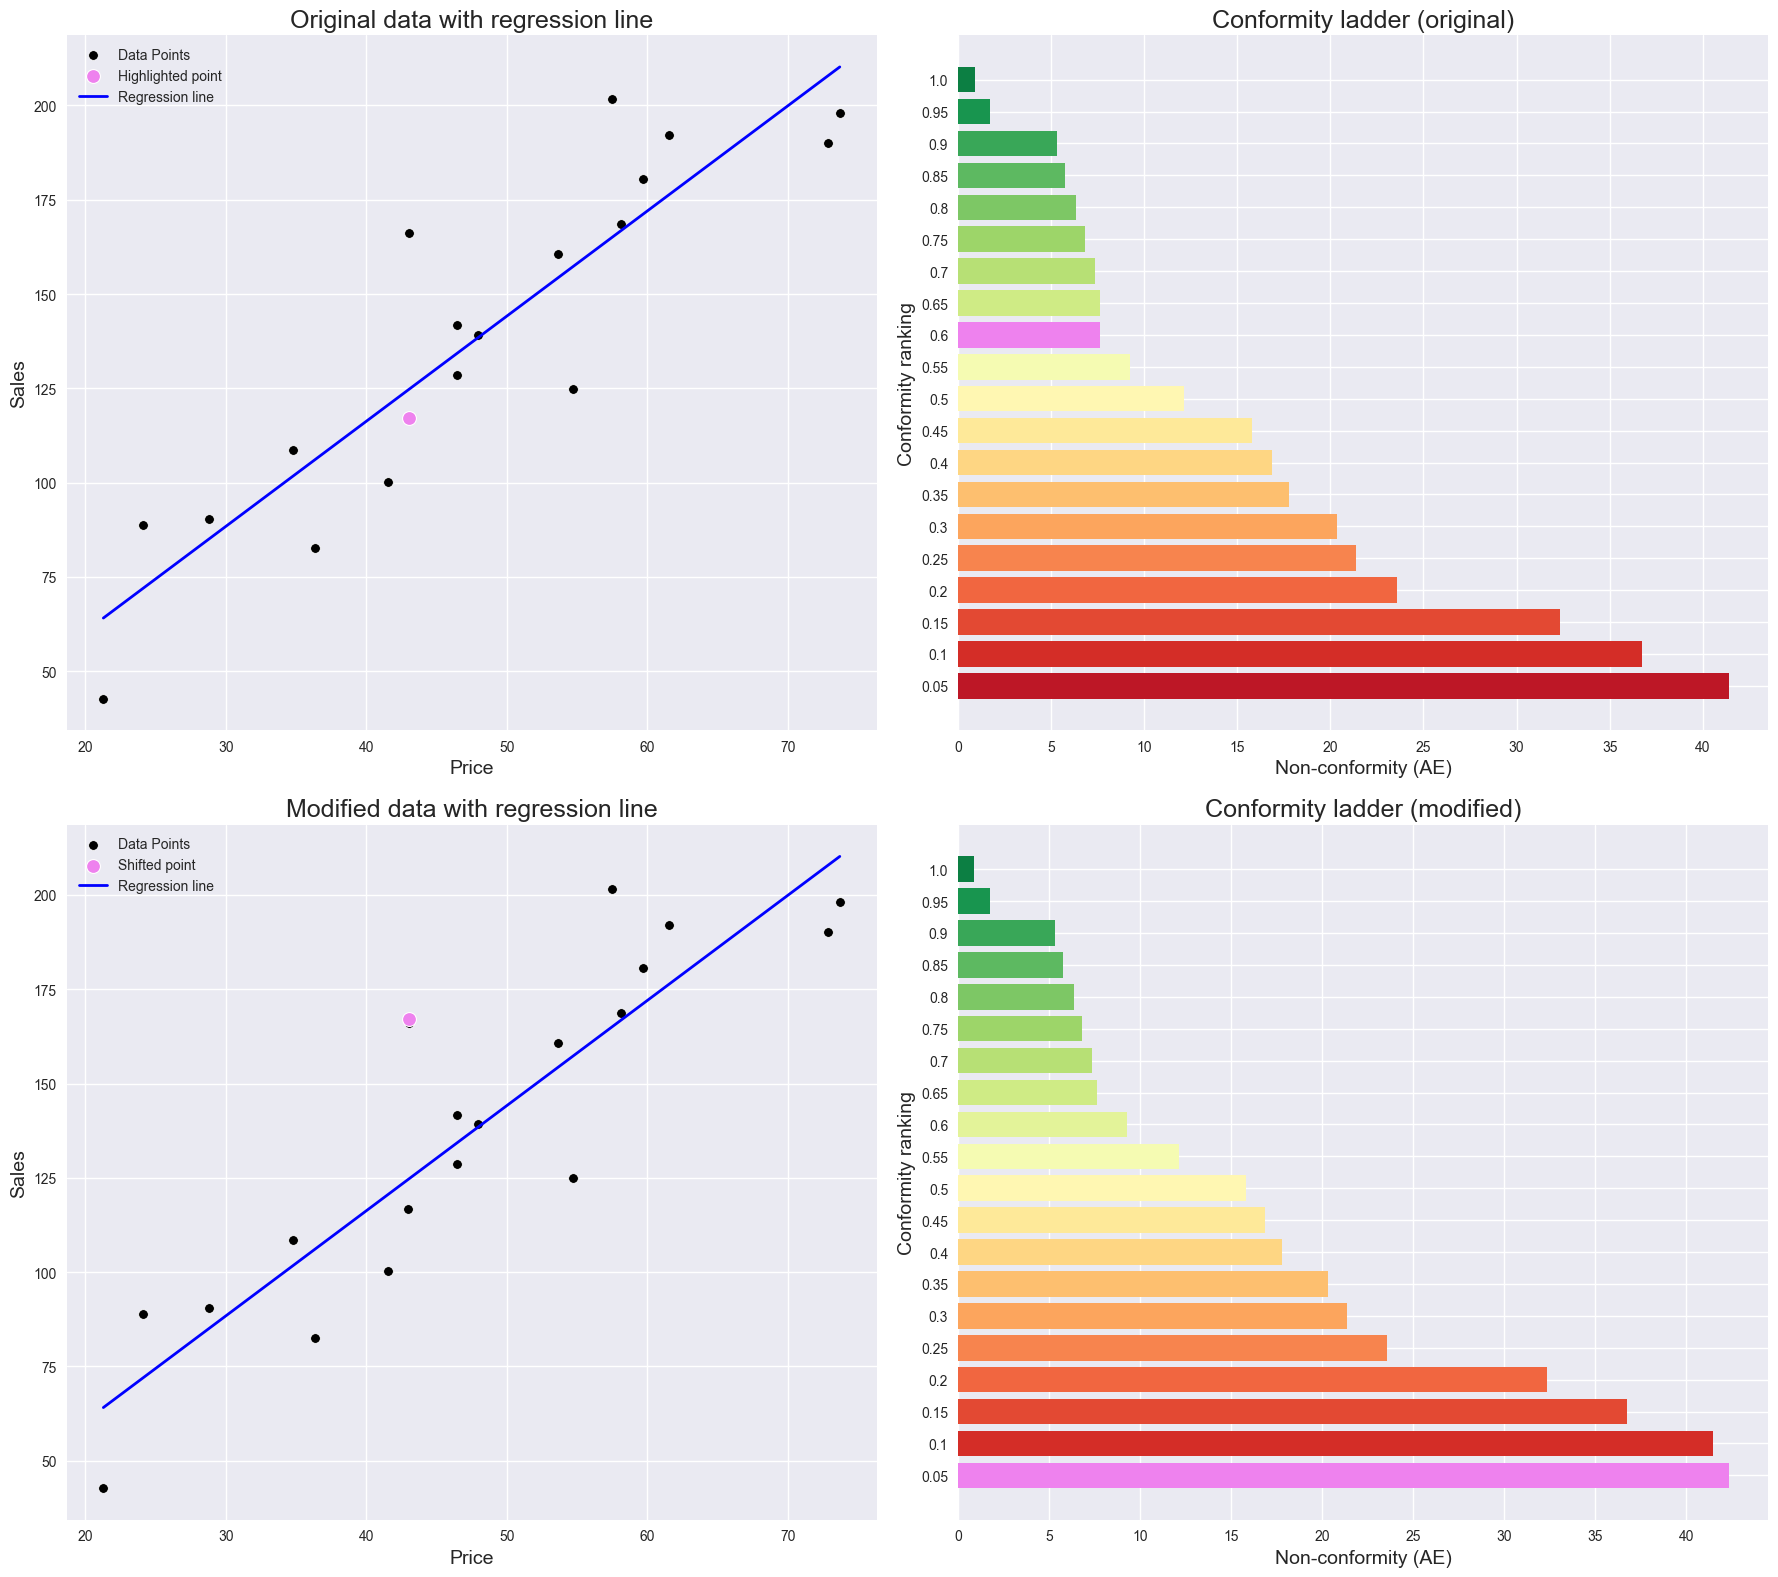

In [32]:
np.random.seed(42)
x = np.random.normal(50, 15, 20)
y_noisy = x * 3 + np.random.normal(0, 20, 20)

model_noisy = LinearRegression().fit(x.reshape(-1, 1), y_noisy)
y_pred_noisy = model_noisy.predict(x.reshape(-1, 1))
abs_errors_noisy = np.abs(y_pred_noisy - y_noisy)

# Shift one point to an extreme
x_modified = x.copy()
y_modified = y_noisy.copy()
y_modified[10] += 50

y_pred_modified = model_noisy.predict(x_modified.reshape(-1, 1))
abs_errors_modified = np.abs(y_pred_modified - y_modified)

# Conformity scores (higher = more conforming)
conformity_scores_noisy = 1 - np.argsort(np.argsort(abs_errors_noisy)) / len(abs_errors_noisy)
conformity_scores_modified = 1 - np.argsort(np.argsort(abs_errors_modified)) / len(abs_errors_modified)

sorted_indices_noisy = np.argsort(-conformity_scores_noisy)
sorted_indices_modified = np.argsort(-conformity_scores_modified)

colors_noisy = [sns.color_palette("RdYlGn_r", n_colors=len(abs_errors_noisy))[i] for i in range(len(abs_errors_noisy))]
colors_modified = [sns.color_palette("RdYlGn_r", n_colors=len(abs_errors_modified))[i] for i in range(len(abs_errors_modified))]

highlight_index = 10
highlight_color = "violet"

fig, ax = plt.subplots(2, 2, figsize=(18, 16))

# Original data
sns.scatterplot(x=x, y=y_noisy, ax=ax[0,0], color="black", label="Data Points")
sns.scatterplot(x=[x[10]], y=[y_noisy[10]], ax=ax[0,0], color="violet", s=100, label="Highlighted point")
sns.lineplot(x=x, y=y_pred_noisy, ax=ax[0,0], color="blue", label="Regression line")
ax[0,0].set_title("Original data with regression line")
ax[0,0].set_xlabel("Price"); ax[0,0].set_ylabel("Sales"); ax[0,0].legend()

# Original ladder
bar_colors = colors_noisy.copy()
bar_colors[sorted_indices_noisy.tolist().index(highlight_index)] = highlight_color
ax[0,1].barh(np.arange(len(conformity_scores_noisy)), abs_errors_noisy[sorted_indices_noisy], color=bar_colors)
ax[0,1].set_yticks(np.arange(len(conformity_scores_noisy)))
ax[0,1].set_yticklabels(np.round(conformity_scores_noisy[sorted_indices_noisy], 2))
ax[0,1].set_title("Conformity ladder (original)")
ax[0,1].set_xlabel("Non-conformity (AE)"); ax[0,1].set_ylabel("Conformity ranking"); ax[0,1].invert_yaxis()

# Modified data
sns.scatterplot(x=x_modified, y=y_modified, ax=ax[1,0], color="black", label="Data Points")
sns.scatterplot(x=[x_modified[10]], y=[y_modified[10]], ax=ax[1,0], color="violet", s=100, label="Shifted point")
sns.lineplot(x=x_modified, y=y_pred_modified, ax=ax[1,0], color="blue", label="Regression line")
ax[1,0].set_title("Modified data with regression line")
ax[1,0].set_xlabel("Price"); ax[1,0].set_ylabel("Sales"); ax[1,0].legend()

# Modified ladder
bar_colors_mod = colors_modified.copy()
bar_colors_mod[sorted_indices_modified.tolist().index(highlight_index)] = highlight_color
ax[1,1].barh(np.arange(len(conformity_scores_modified)), abs_errors_modified[sorted_indices_modified], color=bar_colors_mod)
ax[1,1].set_yticks(np.arange(len(conformity_scores_modified)))
ax[1,1].set_yticklabels(np.round(conformity_scores_modified[sorted_indices_modified], 2))
ax[1,1].set_title("Conformity ladder (modified)")
ax[1,1].set_xlabel("Non-conformity (AE)"); ax[1,1].set_ylabel("Conformity ranking"); ax[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Split conformal method

The fix for full conformal: split into training and calibration sets. Train the model on one, compute non-conformity on the other. Now we can move validation points without refitting.

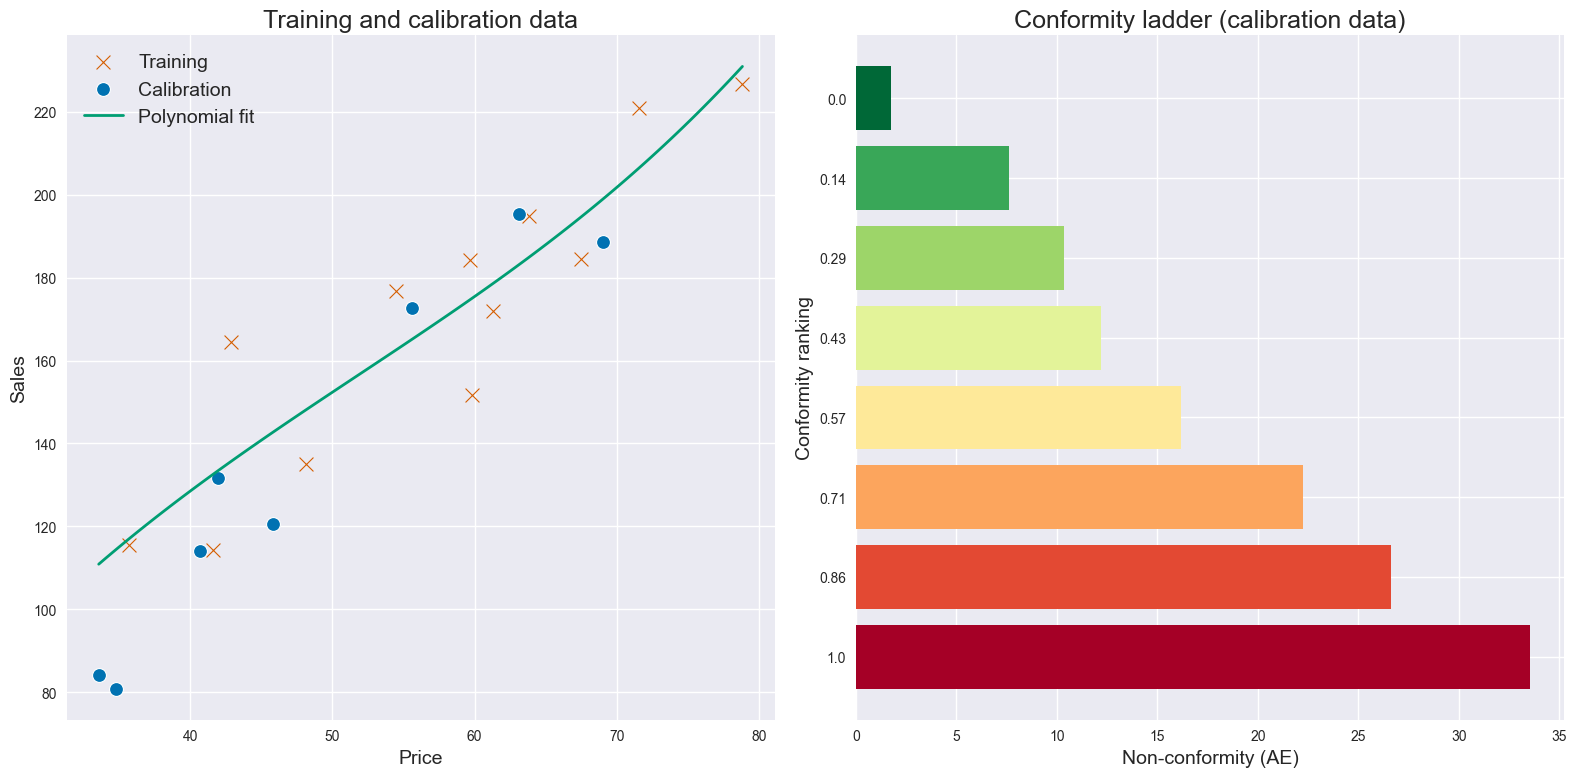

In [33]:
np.random.seed(39285)
x = np.random.normal(50, 15, 20)
y = x * 3 + np.random.normal(0, 20, 20)

x_train, x_calib, y_train, y_calib = train_test_split(x, y, test_size=0.4, random_state=42)

poly = PolynomialFeatures(degree=3)
x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
x_calib_poly = poly.transform(x_calib.reshape(-1, 1))

model = LinearRegression().fit(x_train_poly, y_train)
y_calib_pred = model.predict(x_calib_poly)

abs_errors_calib = np.abs(y_calib_pred - y_calib)
ranks = np.argsort(np.argsort(abs_errors_calib))
conformity_scores = ranks / (len(abs_errors_calib) - 1)
sorted_indices_calib = np.argsort(conformity_scores)

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

sns.scatterplot(x=x_train, y=y_train, ax=axs[0], marker='x', color=custom_palette[2], s=100, label="Training")
sns.scatterplot(x=x_calib, y=y_calib, ax=axs[0], marker='o', color=custom_palette[1], s=100, label="Calibration")
x_range = np.linspace(min(x), max(x), 100)
sns.lineplot(x=x_range, y=model.predict(poly.transform(x_range.reshape(-1, 1))), 
             ax=axs[0], color=custom_palette[3], label="Polynomial fit")
axs[0].set_title("Training and calibration data"); axs[0].set_xlabel("Price"); axs[0].set_ylabel("Sales")
axs[0].legend(fontsize=14)

norm = plt.Normalize(conformity_scores.min(), conformity_scores.max())
colors = plt.cm.RdYlGn_r(norm(conformity_scores[sorted_indices_calib]))
axs[1].barh(np.arange(len(conformity_scores)), abs_errors_calib[sorted_indices_calib], color=colors)
axs[1].set_yticks(np.arange(len(conformity_scores)))
axs[1].set_yticklabels(np.round(conformity_scores[sorted_indices_calib], 2))
axs[1].set_title("Conformity ladder (calibration data)")
axs[1].set_xlabel("Non-conformity (AE)"); axs[1].set_ylabel("Conformity ranking"); axs[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Applied: EnbPI conformal intervals with PyTorch + MAPIE

We train a feedforward network on pseudo sales data, wrap it for scikit-learn compatibility, and apply MAPIE's EnbPI method to generate conformal prediction intervals.

### 6.1 Data loading and feature engineering

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data — adjust path to your setup
data = pd.read_csv(r"C:\Users\Graeme\Documents\github\tsfwpt\data\pseudo_sales.csv")
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y')
data = data.sort_values('date').reset_index(drop=True)

def add_datetime_features(df, datetime_column):
    df = df.copy()
    df[datetime_column] = pd.to_datetime(df[datetime_column])
    df['year'] = df[datetime_column].dt.year
    df['month'] = df[datetime_column].dt.month
    df['week'] = df[datetime_column].dt.isocalendar().week.astype(int)
    df['day'] = df[datetime_column].dt.day
    return df

df = add_datetime_features(data, "date")
date_col = df['date'].copy()
target = df['sales'].copy()
features = df.drop(columns=['sales', 'date']).copy()

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
features_scaled = feature_scaler.fit_transform(features)
target_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

def create_time_windows(features, target, window_size):
    inputs, targets = [], []
    for i in range(len(features) - window_size):
        inputs.append(features[i:i + window_size])
        targets.append(target[i + window_size])
    return np.array(inputs), np.array(targets)

window_size = 32
inputs, targets = create_time_windows(features_scaled, target_scaled, window_size)
print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")

Inputs shape: (698, 32, 8), Targets shape: (698, 1)


### 6.2 Dataset, splits, and dataloaders

We preserve temporal order — no shuffling.

In [35]:
class TimeSeriesDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.tensor(inputs, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

train_size = int(0.6 * len(inputs))
val_size = int(0.2 * len(inputs))

train_dataset = TimeSeriesDataset(inputs[:train_size], targets[:train_size])
val_dataset = TimeSeriesDataset(inputs[train_size:train_size + val_size], targets[train_size:train_size + val_size])
test_dataset = TimeSeriesDataset(inputs[train_size + val_size:], targets[train_size + val_size:])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 418, Val: 139, Test: 141


### 6.3 Model definition and training

Same FFN architecture as Chapter 6, with Optuna-tuned hyperparameters.

In [36]:
class FFNetwork(L.LightningModule):
    def __init__(self, input_dim, sequence_length, hidden_dim, 
                 num_layers=1, output_dim=1, learning_rate=0.0001, 
                 dropout_rate=0.5, activation_func=nn.ReLU()):
        super(FFNetwork, self).__init__()
        self.layers = nn.ModuleList([nn.Linear(input_dim * sequence_length, hidden_dim)])
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.layers.append(nn.Linear(hidden_dim, output_dim))
        self.dropout = nn.Dropout(dropout_rate)
        self.activation = activation_func
        self.learning_rate = learning_rate

    def forward(self, x):
        batch_size, sequence_length, input_dim = x.size()
        x = x.view(batch_size, sequence_length * input_dim)
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
            x = self.dropout(x)
        return self.layers[-1](x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self.forward(x), y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self.forward(x), y)
        self.log('val_loss', loss)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

input_dim = inputs.shape[2]
sequence_length = inputs.shape[1]

model = FFNetwork(
    input_dim=input_dim, sequence_length=sequence_length,
    hidden_dim=63, num_layers=4, output_dim=1,
    learning_rate=0.000689, dropout_rate=0.170971
).to(device)

trainer = L.Trainer(
    accelerator="auto", devices=1, max_epochs=300,
    callbacks=[EarlyStopping(monitor='val_loss', patience=50, mode='min')],
    logger=True
)
trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name       | Type       | Params | Mode 
--------------------------------------------------
0 | layers     | ModuleList | 28.4 K | train
1 | dropout    | Dropout    | 0      | train
2 | activation | ReLU       | 0      | train
--------------------------------------------------
28.4 K    Trainable params
0         Non-trainable params
28.4 K    Total params
0.113     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:298: The number of trainin

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

### 6.4 Scikit-learn wrapper for MAPIE

MAPIE expects a scikit-learn compatible estimator. Our wrapper reshapes the flattened 2D input back to the 3D shape the FFN expects.

In [37]:
from sklearn.base import BaseEstimator, RegressorMixin

class SklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, window_size, n_features, device='cpu'):
        self.model = model
        self.window_size = window_size
        self.n_features = n_features
        self.device = device
        self.model.to(self.device)

    def fit(self, X, y):
        return self  # model is pre-trained

    def predict(self, X):
        self.model.eval()
        X_3d = X.reshape(-1, self.window_size, self.n_features)
        X_tensor = torch.tensor(X_3d, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            predictions = self.model(X_tensor).cpu().numpy()
        return predictions.squeeze()

n_features = inputs.shape[2]
wrapped_model = SklearnWrapper(model, window_size=window_size, n_features=n_features, device='cpu')

def extract_data_from_loader(loader):
    inputs_list, targets_list = [], []
    for batch in loader:
        inp, tgt = batch
        inputs_list.append(inp.cpu().numpy())
        targets_list.append(tgt.cpu().numpy())
    return np.vstack(inputs_list), np.concatenate(targets_list)

X_train, y_train = extract_data_from_loader(train_loader)
X_test, y_test = extract_data_from_loader(test_loader)

# Flatten for MAPIE: (samples, window_size, features) → (samples, window_size * features)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
y_train = y_train.ravel()
y_test = y_test.ravel()

### 6.5 EnbPI conformal intervals

Block bootstrapping respects temporal structure by resampling contiguous blocks rather than individual observations.

In [38]:
from mapie.regression import TimeSeriesRegressor
from mapie.subsample import BlockBootstrap
 
confidence_level = 0.9  # 90% prediction intervals
 
cv_mapiets = BlockBootstrap(
    n_resamplings=10, n_blocks=10, overlapping=False, random_state=59
)
mapie_enbpi = TimeSeriesRegressor(
    wrapped_model, method="enbpi", cv=cv_mapiets, 
    agg_function="mean", n_jobs=1
)
mapie_enbpi.fit(X_train, y_train)
 
y_pred_enbpi, y_pis_enbpi = mapie_enbpi.predict(
    X_test, confidence_level=confidence_level, ensemble=True
)

### 6.6 Evaluating conformal interval quality

Two metrics: coverage (does the interval contain the true value?) and width (how tight?).

In [39]:
# Check output shape — MAPIE versions differ
print(f"Predictions shape: {y_pred_enbpi.shape}")
print(f"Intervals shape: {y_pis_enbpi.shape}")

# Handle both 2D and 3D output shapes
if y_pis_enbpi.ndim == 3:
    y_lower = y_pis_enbpi[:, 0, 0]
    y_upper = y_pis_enbpi[:, 1, 0]
else:
    y_lower = y_pis_enbpi[:, 0]
    y_upper = y_pis_enbpi[:, 1]

in_interval = (y_test >= y_lower) & (y_test <= y_upper)
coverage = float(in_interval.mean())
width = float(np.mean(y_upper - y_lower))

print(f"Target coverage: {confidence_level:.0%}")
print(f"Achieved coverage: {coverage:.3f}")
print(f"Mean interval width: {width:.3f}")

Predictions shape: (141,)
Intervals shape: (141, 2, 1)
Target coverage: 90%
Achieved coverage: 0.894
Mean interval width: 0.174


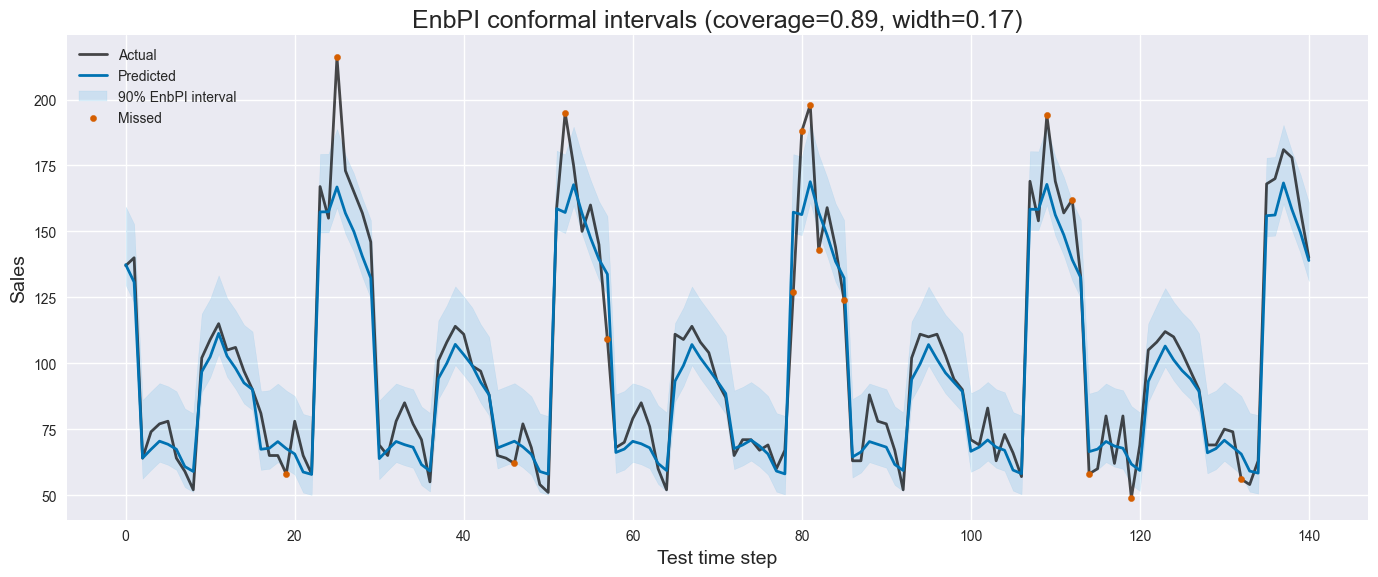

In [40]:
# Inverse transform to original scale for plotting
y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_orig = target_scaler.inverse_transform(y_pred_enbpi.reshape(-1, 1)).ravel()
y_lower_orig = target_scaler.inverse_transform(y_lower.reshape(-1, 1)).ravel()
y_upper_orig = target_scaler.inverse_transform(y_upper.reshape(-1, 1)).ravel()

in_interval_orig = (y_test_orig >= y_lower_orig) & (y_test_orig <= y_upper_orig)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(y_test_orig, color=custom_palette[0], alpha=0.7, label="Actual")
ax1.plot(y_pred_orig, color=custom_palette[1], label="Predicted")
ax1.fill_between(
    range(len(y_test_orig)),
    y_lower_orig,
    y_upper_orig,
    alpha=0.2,
    color=custom_palette[5],
    label=f"{confidence_level:.0%} EnbPI interval"
)
ax1.scatter(
    np.where(~in_interval_orig)[0],
    y_test_orig[~in_interval_orig],
    color=custom_palette[2],
    s=20,
    zorder=5,
    label="Missed"
)
ax1.set_xlabel("Test time step")
ax1.set_ylabel("Sales")
ax1.set_title(f"EnbPI conformal intervals (coverage={coverage:.2f}, width={width:.2f})")
ax1.legend()

plt.tight_layout()
plt.show()

# 6.7 Partial fit 

### Adaptive EnbPI with `partial_fit()`

The basic EnbPI we used above produces constant-width intervals, it has the same quantile is applied to every test point regardless of how the model has been performing 'recently'. Of course, forecast difficulty changes with time. A model may predict well during stable periods and poorly during regime changes, promotions, or seasonal transitions. Constant-width intervals don't reflect this as they are either too wide when a model is performing well (inefficient) or too narrow when conditions shift (unsafe).

Adaptive EnbPI addresses this by updating our data's residual distribution as new observations arrive. After each prediction, we reveal the true value and use `partial_fit()` to add a new residual to our distribution and can (optionally) drop the oldest one residual. The quantile used for the next interval is then computed from this updated distribution. No model retraining is required, we are only updating the calibration residuals.

Folling this approach intervals widen when recent errors are large and narrow when a model is tracking data well. This is the same idea behind Adaptive Conformal Inference (ACI), where the miscoverage rate $\alpha$ is adjusted online based on whether recent intervals have been hitting or missing.

In [ ]:
## Adaptive EnbPI with MAPIE (partial_fit)
# 
# Basic EnbPI produces constant-width intervals because the residual 
# distribution is fixed at training time. The adaptive version updates 
# residuals as new observations arrive, producing intervals that widen 
# or narrow in response to changing forecast difficulty.

from mapie.regression import TimeSeriesRegressor
from mapie.subsample import BlockBootstrap

confidence_level = 0.9

cv_mapiets = BlockBootstrap(
    n_resamplings=10, n_blocks=10, overlapping=False, random_state=59
)
mapie_adaptive = TimeSeriesRegressor(
    wrapped_model, method="enbpi", cv=cv_mapiets,
    agg_function="mean", n_jobs=1
)
mapie_adaptive.fit(X_train, y_train)

# Step through the test set, updating residuals after each observation
y_pred_adaptive = np.zeros(len(X_test))
y_lower_adaptive = np.zeros(len(X_test))
y_upper_adaptive = np.zeros(len(X_test))

for i in range(len(X_test)):
    pred, pis = mapie_adaptive.predict(
        X_test[i:i+1], confidence_level=confidence_level, ensemble=True
    )
    y_pred_adaptive[i] = pred[0]
    
    if pis.ndim == 3:
        y_lower_adaptive[i] = pis[0, 0, 0]
        y_upper_adaptive[i] = pis[0, 1, 0]
    else:
        y_lower_adaptive[i] = pis[0, 0]
        y_upper_adaptive[i] = pis[0, 1]
    
    # Update residuals with the true value
    mapie_adaptive.partial_fit(X_test[i:i+1], y_test[i:i+1])

# Inverse transform
y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_orig = target_scaler.inverse_transform(y_pred_adaptive.reshape(-1, 1)).ravel()
y_lower_orig = target_scaler.inverse_transform(y_lower_adaptive.reshape(-1, 1)).ravel()
y_upper_orig = target_scaler.inverse_transform(y_upper_adaptive.reshape(-1, 1)).ravel()

in_interval = (y_test_orig >= y_lower_orig) & (y_test_orig <= y_upper_orig)
coverage = in_interval.mean()
widths = y_upper_orig - y_lower_orig

print(f"Adaptive EnbPI - Coverage: {coverage:.3f}, Mean width: {np.mean(widths):.3f}")

In [41]:
# %% [markdown]
# ### 6.5 EnbPI conformal intervals with sequential update
#
# Keep the fitted PyTorch FFN frozen. MAPIE updates only the conformal state
# as new labelled observations arrive.

# %%
from mapie.regression import TimeSeriesRegressor
from mapie.subsample import BlockBootstrap

confidence_level = 0.90
step_size = 1  # one-step-ahead sequential updating

cv_mapiets = BlockBootstrap(
    n_resamplings=10,
    n_blocks=10,
    overlapping=False,
    random_state=59
)

mapie_enbpi = TimeSeriesRegressor(
    estimator=wrapped_model,
    method="enbpi",
    cv=cv_mapiets,
    agg_function="mean",
    n_jobs=1
)

# Fit once on the training set
mapie_enbpi.fit(X_train, y_train)

# Storage for sequential predictions and intervals
n_test = len(X_test)
y_pred_enbpi = np.empty(n_test, dtype=float)
y_pis_enbpi = np.empty((n_test, 2, 1), dtype=float)

# First prediction block
first_end = min(step_size, n_test)
y_pred_block, y_pis_block = mapie_enbpi.predict(
    X_test[:first_end],
    confidence_level=confidence_level,
    ensemble=True
)

y_pred_enbpi[:first_end] = np.asarray(y_pred_block).reshape(-1)

# Handle both possible interval output shapes robustly
y_pis_block = np.asarray(y_pis_block)
if y_pis_block.ndim == 2:
    y_pis_block = y_pis_block[:, :, np.newaxis]

y_pis_enbpi[:first_end, :, :] = y_pis_block

# Sequentially update MAPIE with observed labels, then predict next step(s)
for start in range(first_end, n_test, step_size):
    prev_start = start - step_size
    prev_end = start

    # Update conformal state with the newly observed true values
    mapie_enbpi.update(
        X_test[prev_start:prev_end],
        y_test[prev_start:prev_end]
    )

    end = min(start + step_size, n_test)

    y_pred_block, y_pis_block = mapie_enbpi.predict(
        X_test[start:end],
        confidence_level=confidence_level,
        ensemble=True
    )

    y_pred_enbpi[start:end] = np.asarray(y_pred_block).reshape(-1)

    y_pis_block = np.asarray(y_pis_block)
    if y_pis_block.ndim == 2:
        y_pis_block = y_pis_block[:, :, np.newaxis]

    y_pis_enbpi[start:end, :, :] = y_pis_block

print(f"Predictions shape: {y_pred_enbpi.shape}")
print(f"Intervals shape: {y_pis_enbpi.shape}")

c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\mapie\regression\time_series_regression.py:379: UserWarning: 
        This function behavior has been changed to allow updating the scores even when using ACI.
        Currently the parameters confidence_level and optimize_beta have no effect. They are kept
        for API stability and will be removed in a future release.
        If you want to adapt confidence level, use adapt_conformal_inference instead.
        
  warn("""


Predictions shape: (141,)
Intervals shape: (141, 2, 1)


In [42]:
# %% [markdown]
# ### 6.6 Evaluating conformal interval quality

# %%
# Explicit interval extraction for MAPIE current shape: (n_samples, 2, n_confidence_levels)
y_lower = y_pis_enbpi[:, 0, 0]
y_upper = y_pis_enbpi[:, 1, 0]

in_interval = (y_test >= y_lower) & (y_test <= y_upper)
coverage = float(in_interval.mean())
width = float(np.mean(y_upper - y_lower))

print(f"Target coverage: {confidence_level:.0%}")
print(f"Achieved coverage: {coverage:.3f}")
print(f"Mean interval width: {width:.3f}")

Target coverage: 90%
Achieved coverage: 0.894
Mean interval width: 0.176


In [43]:
# %%
# Inverse transform to original scale for plotting / interpretation
y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_orig = target_scaler.inverse_transform(y_pred_enbpi.reshape(-1, 1)).ravel()
y_lower_orig = target_scaler.inverse_transform(y_lower.reshape(-1, 1)).ravel()
y_upper_orig = target_scaler.inverse_transform(y_upper.reshape(-1, 1)).ravel()

in_interval_orig = (y_test_orig >= y_lower_orig) & (y_test_orig <= y_upper_orig)
widths_orig = y_upper_orig - y_lower_orig

print(f"Original-scale coverage: {in_interval_orig.mean():.3f}")
print(f"Original-scale mean width: {np.mean(widths_orig):.3f}")

Original-scale coverage: 0.894
Original-scale mean width: 30.094


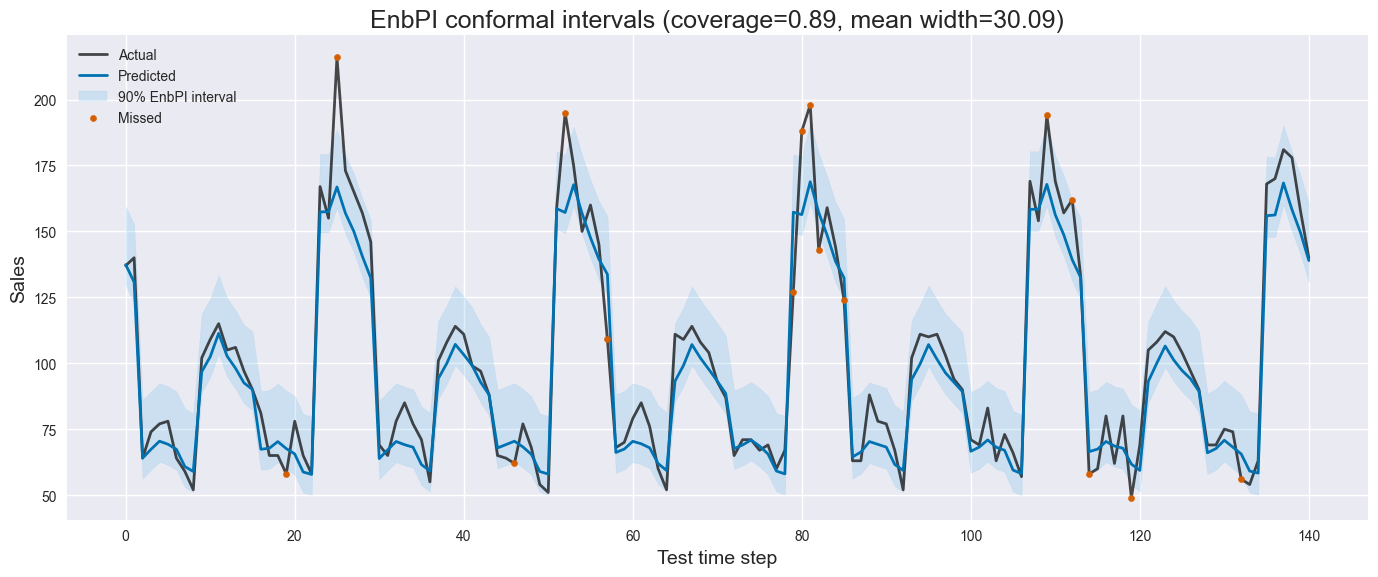

In [44]:
# %%
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(y_test_orig, color=custom_palette[0], alpha=0.7, label="Actual")
ax1.plot(y_pred_orig, color=custom_palette[1], label="Predicted")
ax1.fill_between(
    range(len(y_test_orig)),
    y_lower_orig,
    y_upper_orig,
    alpha=0.2,
    color=custom_palette[5],
    label=f"{confidence_level:.0%} EnbPI interval"
)
ax1.scatter(
    np.where(~in_interval_orig)[0],
    y_test_orig[~in_interval_orig],
    color=custom_palette[2],
    s=20,
    zorder=5,
    label="Missed"
)

ax1.set_xlabel("Test time step")
ax1.set_ylabel("Sales")
ax1.set_title(
    f"EnbPI conformal intervals "
    f"(coverage={in_interval_orig.mean():.2f}, mean width={np.mean(widths_orig):.2f})"
)
ax1.legend()

plt.tight_layout()
plt.show()

---

## 7. Conformal prediction with Darts

Darts wraps conformal prediction around any pre-trained global model using `ConformalNaiveModel`. No separate calibration split needed — Darts extracts it automatically from the series history.

We use an NLinear model as the base forecaster on our pseudo sales data.

In [ ]:
# # pip install darts

# from darts import TimeSeries
# from darts.models import NLinearModel, ConformalNaiveModel
# from darts.dataprocessing.transformers import Scaler

# data = pd.read_csv(r'C:\Users\Graeme\Documents\github\tsfwpt\das_buch\data\chapter7\pseudo_sales.csv')
# data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y')
# data = data.sort_values('date').reset_index(drop=True)

# series = TimeSeries.from_dataframe(data, time_col='date', value_cols='sales', freq='D')

# scaler = Scaler()
# series_scaled = scaler.fit_transform(series)

# # Train / calibration / test split
# train, temp = series_scaled[:-120], series_scaled[-120:]
# cal, test = temp[:60], temp[60:]

# # Train a simple model — no exogenous
# base_model = NLinearModel(
#     input_chunk_length=32,
#     output_chunk_length=1,
#     n_epochs=100,
#     random_state=42
# )
# base_model.fit(train)

# # Wrap with conformal prediction — 90% interval
# conformal_model = ConformalNaiveModel(
#     model=base_model,
#     quantiles=[0.05, 0.5, 0.95],
#     cal_length=60,
# )

# # Predict
# pred = conformal_model.predict(
#     n=len(test),
#     series=train.append(cal),
#     num_samples=200,
# )

# # Inverse transform and plot
# pred_orig = scaler.inverse_transform(pred)
# test_orig = scaler.inverse_transform(test)

# fig, ax = plt.subplots(figsize=(14, 6))
# test_orig.plot(label="Actual", ax=ax, color=custom_palette[0])
# pred_orig.plot(label="Darts NLinear + conformal", ax=ax, color=custom_palette[1])
# ax.set_title("Darts: conformal prediction intervals (90%)")
# ax.legend()
# plt.tight_layout()
# plt.show()

## 8. Conformal prediction with NeuralForecast

NeuralForecast provides conformal prediction via `PredictionIntervals`, which uses cross-validation on a point-loss model to generate calibrated intervals. No separate calibration set needed.

We use NHITS as the base model.

In [ ]:
#!pip install neuralforecast --upgrade

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import MAE
from neuralforecast.utils import PredictionIntervals

data = pd.read_csv(r'C:\Users\Graeme\Documents\github\tsfwpt\das_buch\data\chapter7\pseudo_sales.csv')
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y')
data = data.sort_values('date').reset_index(drop=True)

# NeuralForecast long format — no exogenous, just unique_id / ds / y
nf_df = data.rename(columns={'date': 'ds', 'sales': 'y'})
nf_df['unique_id'] = 'pseudo_sales'
nf_df = nf_df[['unique_id', 'ds', 'y']]

horizon = 60
train_df = nf_df.iloc[:-horizon]
test_df = nf_df.iloc[-horizon:]

prediction_intervals = PredictionIntervals(n_windows=5, method="enbpi", agg_function="mean", n_jobs=-1, random_state=7356)

models = [
    MLP(
        h=horizon,
        input_size=32,
        max_steps=200,
        loss=MAE(),
        scaler_type="robust",
        random_seed=42
    )
]

nf = NeuralForecast(models=models, freq='D')
nf.fit(train_df, prediction_intervals=prediction_intervals)

forecasts = nf.predict(level=[90])
print(forecasts.columns.tolist())

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

recent = nf_df.iloc[-180:]
ax.plot(recent['ds'], recent['y'], color=custom_palette[0], alpha=0.7, label='Actual')
ax.plot(forecasts['ds'], forecasts['MLP'], color=custom_palette[1], label='MLP forecast')
ax.fill_between(
    forecasts['ds'],
    forecasts['MLP-lo-90'],
    forecasts['MLP-hi-90'],
    alpha=0.2, color=custom_palette[5], label='90% conformal interval'
)
ax.set_title("NeuralForecast: MLP with conformal prediction intervals (90%)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()

# Coverage
merged = test_df.merge(forecasts, on=['unique_id', 'ds'])
in_interval = (merged['y'] >= merged['MLP-lo-90']) & (merged['y'] <= merged['MLP-hi-90'])
print(f"Coverage: {in_interval.mean():.3f}")
print(f"Mean width: {(merged['MLP-hi-90'] - merged['MLP-lo-90']).mean():.3f}")

---

## Notes

- The MAPIE example uses `MapieTimeSeriesRegressor` — check your installed version, as the API has changed across releases. Older versions use `alpha` (miscoverage), newer versions may use `confidence_level` (coverage).
- The Darts example uses `ConformalNaiveModel` which applies symmetric split conformal prediction. `ConformalQRModel` is available for asymmetric intervals.
- The NeuralForecast example uses `PredictionIntervals()` with default settings (cross-validation based). The `level` parameter in `predict()` controls the interval width.
- All three approaches produce conformal intervals — the differences are in how they handle calibration, temporal structure, and the user-facing API.